# 5. 地動觀測：波形與地震目錄

「地動」資料有兩種形態：

1. **連續波形**：地震儀記錄的原始震動訊號（本章用 miniSEED 格式 + ObsPy）
2. **地震目錄**：氣象署從波形定位出的每一次地震（時間、位置、規模、深度）

## 5.1 讀波形：2024 花蓮地震的主震記錄

第 2 章已下載花蓮氣象站（HWA）寬頻頻道 `HH?`（100 Hz）在主震前後
一小時的連續波形：

In [1]:
from gdms_toolkit.viz import setup_plotly
setup_plotly()

In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

import gdms_toolkit as gt
from gdms_toolkit.download import CACHE_DIR
from gdms_toolkit.viz import ACCENT, QUAKE_COLOR, SEQUENTIAL, apply_layout

st = gt.read_waveform(CACHE_DIR / "edu-wave-hualien2024.mseed")
print(st)

3 Trace(s) in Stream:
TW.HWA.00.HH1 | 2024-04-02T23:30:00.000000Z - 2024-04-03T00:29:59.990000Z | 100.0 Hz, 360000 samples
TW.HWA.00.HH2 | 2024-04-02T23:30:00.000000Z - 2024-04-03T00:29:59.990000Z | 100.0 Hz, 360000 samples
TW.HWA.00.HHZ | 2024-04-02T23:30:00.000000Z - 2024-04-03T00:29:59.990000Z | 100.0 Hz, 360000 samples


一個 `Stream` 內含三個 `Trace`：HHZ（垂直）、HH1／HH2（兩水平）。
ObsPy 內建繪圖（matplotlib）：

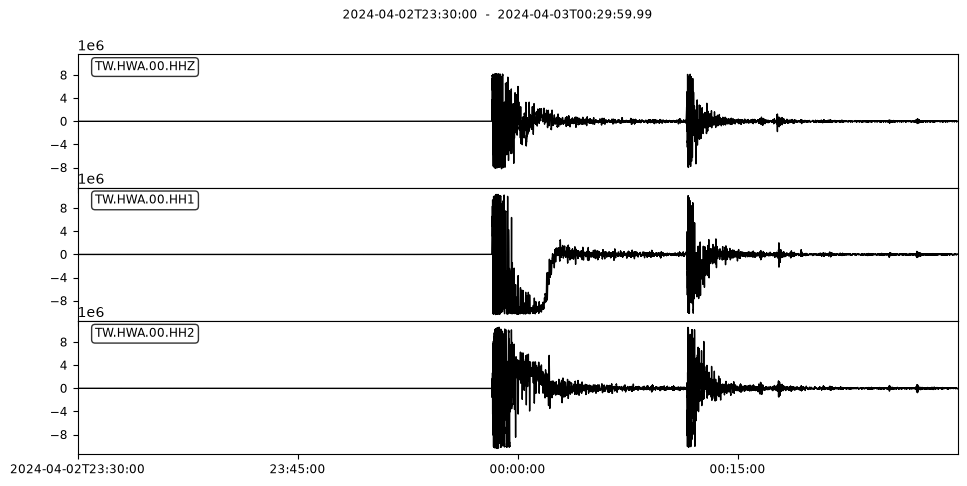

In [3]:
_ = st.plot(size=(1000, 500))

主震（UTC 23:58:11）的震波在 23:58 後抵達花蓮站，振幅大到把
前面 28 分鐘的背景噪訊完全壓扁。

## 5.2 基本波形處理：去趨勢、濾波、找 P 波

標準流程是去均值、去趨勢，再帶通濾波：

In [4]:
tr = st.select(channel="HHZ")[0].copy()
tr.detrend("demean").detrend("linear")
tr.filter("bandpass", freqmin=0.5, freqmax=10)

t = pd.to_datetime(tr.times("timestamp"), unit="s", utc=True)
sub = slice(int(27.5 * 60 * 100), int(31 * 60 * 100))  # 主震前後幾分鐘
fig = go.Figure(go.Scattergl(x=t[sub], y=tr.data[sub], mode="lines",
                             line=dict(color=ACCENT, width=1)))
fig.add_vline(x="2024-04-02 23:58:11", line_dash="dash", line_color=QUAKE_COLOR)
apply_layout(fig, title="HWA.HHZ 帶通 0.5–10 Hz（紅線＝發震時刻）",
             yaxis_title="速度（counts）", showlegend=False, hovermode=False)
fig

發震時刻（紅線）與波形起跳之間有一段延遲，因為震波從震源傳到測站需要時間。
震央距花蓮站約 12 公里、深約 20 公里，P 波（~6 km/s）約數秒後抵達，
S 波（約 3.5 km/s）再晚幾秒。兩者的到時差，就是單站估算震央距離的依據
（大約 8 × (tS − tP) 公里）。

## 5.3 時頻譜（Spectrogram）

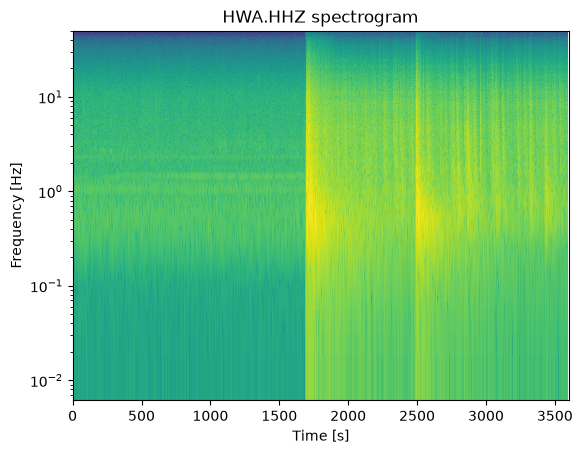

In [5]:
_ = tr.spectrogram(log=True, wlen=10, dbscale=True,
                   title="HWA.HHZ spectrogram")

主震在所有頻段同時「點亮」，之後的餘震一條一條像雨滴。時頻譜很適合用來
快速瀏覽連續資料，辨認事件與噪訊來源。

## 5.4 地震目錄：直接抓成 DataFrame

`gdms_earthquake_catalog()` 直接回傳氣象署正式目錄
（需登入；結果快取成 CSV 避免重複查詢）：

In [6]:
cat_csv = CACHE_DIR / "catalog_2024spring.csv"
if cat_csv.exists():
    cat = pd.read_csv(cat_csv, parse_dates=["time"])
else:
    gdms = gt.GDMSSession()
    cat = gt.gdms_earthquake_catalog(gdms, "2024-03-01", "2024-06-30", min_ml=3)
    cat.to_csv(cat_csv, index=False)
print(f"2024/03–06 ML≥3 共 {len(cat)} 筆")
cat.tail(3)

2024/03–06 ML≥3 共 3006 筆


,event_id,time,latitude,longitude,depth,ML,nstn,dmin,gap,trms,ERH,ERZ,fixed,nph,quality
3003,1565513,2024-06-30 06:52:49.940,24.2887,121.8673,12.11,4.04,99,12.2,87,0.38,0.1,0.2,F,186,C
3004,1565514,2024-06-30 16:45:24.260,24.2297,121.6850,33.43,3.90,99,10.1,61,0.30,0.2,0.1,F,333,B
3005,1565515,2024-06-30 21:09:08.610,24.1693,121.7938,31.06,3.88,99,16.1,64,0.33,0.2,0.1,F,351,B


## 5.5 規模–時間圖（M–T plot）

In [7]:
fig = px.scatter(cat, x="time", y="ML", color="depth",
                 color_continuous_scale=SEQUENTIAL,
                 labels={"time": "時間", "ML": "規模 ML", "depth": "深度（km）"},
                 hover_data={"latitude": ":.2f", "longitude": ":.2f"})
fig.update_traces(marker=dict(size=5, opacity=0.6))
fig.add_vline(x="2024-04-02 23:58", line_dash="dash", line_color=QUAKE_COLOR)
apply_layout(fig, title="規模–時間圖（紅線＝花蓮主震；目錄時間為 UTC，"
                       "當地時間為 4/3 07:58）", hovermode="closest")
fig

主震後地震數量爆炸性增加，這就是餘震序列，並隨時間慢慢衰減
（Omori 定律）。主震前有沒有「前震」？這是無法事先回答的問題：
前震只有在主震發生後才成為前震。

## 5.6 震央分布圖

In [8]:
fig = px.scatter_map(cat, lat="latitude", lon="longitude",
                     size=2 ** cat.ML / 10, color="depth",
                     color_continuous_scale=SEQUENTIAL,
                     hover_data={"time": True, "ML": True},
                     zoom=6.3, center=dict(lat=23.7, lon=121.2),
                     map_style="carto-positron", height=600)
apply_layout(fig, title="2024/03–06 ML≥3 震央分布（點大小∝規模、顏色＝深度）",
             hovermode="closest")
fig

餘震沿花蓮外海–縱谷北段密集成帶，勾勒出破裂面的範圍。

## 5.7 Gutenberg–Richter 定律

地震規模與頻率遵循經驗律 $\log_{10} N = a - bM$：規模每小 1，
數量約多 10 倍。b 值（斜率）的時空變化被認為與應力狀態有關。

In [9]:
mags = np.arange(3, cat.ML.max() + 0.1, 0.1)
N = [(cat.ML >= m).sum() for m in mags]
fig = go.Figure(go.Scatter(x=mags, y=N, mode="markers",
                           marker=dict(color=ACCENT, size=7)))
# 以 3.5–5.5 區間做最小二乘擬合
sel = (mags >= 3.5) & (mags <= 5.5)
b, a = np.polyfit(mags[sel], np.log10(np.array(N)[sel]), 1)
fig.add_trace(go.Scatter(x=mags, y=10 ** (a + b * mags), mode="lines",
                         line=dict(color=QUAKE_COLOR, dash="dash"),
                         name=f"擬合 b = {-b:.2f}"))
apply_layout(fig, title="Gutenberg–Richter：累積次數 vs 規模",
             xaxis_title="規模 ML", yaxis_title="N（ML ≥ M）",
             yaxis_type="log", hovermode="x")
fig

低規模端曲線變平，不是那個規模的地震變少了，而是目錄本身不完整：太小
的地震有些沒被偵測到。這個轉折點對應的規模叫「完整規模」Mc，判讀 b 值
之前一定要先決定它，否則會低估 b 值。

## 5.8 餘震怎麼衰減：Omori 定律

主震後餘震的數量隨時間衰減，經驗上大致遵循冪次律（修正 Omori 定律）。
把主震後 30 天的每日餘震數畫在對數座標上：

In [10]:
main = cat.loc[cat.ML.idxmax()]
aft = cat[cat.time >= main.time].copy()
aft["day"] = ((aft.time - main.time).dt.total_seconds() // 86400).astype(int) + 1
daily_n = aft[aft.day.between(1, 30)].groupby("day").size()

fig = go.Figure(go.Scatter(x=daily_n.index, y=daily_n.values, mode="markers",
                           marker=dict(color=ACCENT, size=8)))
fig.add_trace(go.Scatter(x=daily_n.index, y=daily_n.iloc[0] / daily_n.index,
                         mode="lines", line=dict(color=QUAKE_COLOR, dash="dash"),
                         name="~ 1/t 參考線"))
apply_layout(fig, title="主震後每日餘震數（ML≥3）：冪次衰減",
             xaxis_title="主震後天數", yaxis_title="當日餘震數",
             xaxis_type="log", yaxis_type="log", hovermode="x")
fig

資料點大致沿著一條下降直線排列，接近 1/t 的衰減。第一天就有幾百次
ML≥3 餘震，一週後掉到個位數。這種可預期的衰減，是地震定位人員判斷
「餘震活動是否恢復正常」的依據，也是餘震機率預報的基礎。

## 5.9 b 值會變嗎：主震前後對照

b 值被認為和地殼應力狀態有關，高應力區傾向有較低的 b 值。用最大概似法
分別估計主震前與餘震期的 b 值：

In [11]:
def b_value(magnitudes, mc):
    """Aki (1965) 最大概似法估 b 值。"""
    m = magnitudes[magnitudes >= mc]
    return np.log10(np.e) / (m.mean() - (mc - 0.05))

pre = cat[cat.time < main.time].ML
post = aft[aft.day.between(1, 30)].ML
print(f"主震前（3/1–4/2）：{len(pre)} 筆，b = {b_value(pre, 3.5):.2f}")
print(f"餘震期（30 天）：{len(post)} 筆，b = {b_value(post, 3.5):.2f}")

主震前（3/1–4/2）：208 筆，b = 0.81
餘震期（30 天）：2485 筆，b = 0.67


兩個時期的 b 值確實有差，但先別急著下結論。主震前的樣本數少很多，估計
的不確定度大；而且用不同的完整規模 Mc、不同的時間切法，數字都會跟著
變。b 值分析的困難不在算式，而在它對取樣選擇非常敏感。認真的研究會用
bootstrap 之類的方法給出誤差範圍，才知道兩個數字的差是真的、還是抽樣
的巧合。這也是本課程反覆想傳達的態度：一個數字算得出來，不等於它站得
住腳。

## 參考資料與延伸閱讀

- **操作入門・免費教材**：ObsPy 開發團隊，〈[Tutorial](https://docs.obspy.org/tutorial/)〉。
  依序看 Reading Seismograms、Filtering Seismograms 與 Plotting Spectrograms，把本章的讀檔、濾波及時頻圖流程接起來。
- **工具論文**：Beyreuther et al.（2010），〈[ObsPy: A Python Toolbox for Seismology](https://doi.org/10.1785/gssrl.81.3.530)〉，*Seismological Research Letters*；[出版學會免費全文](https://www.seismosoc.org/Publications/SRL/SRL_81/srl_81-3_es/)。
  了解 ObsPy 如何把不同格式的地震資料接到共同的處理流程；論文用來認識設計背景，程式語法以目前官方文件為準。
- **台灣規模統計・論文**：Wang et al.（2015），〈[b-Values Observations in Taiwan: A Review](https://doi.org/10.3319/TAO.2015.04.28.01%28T%29)〉，*Terrestrial, Atmospheric and Oceanic Sciences*。
  延伸本章的規模－次數圖與震前震後比較，留意目錄品質、取樣區間和構造差異如何影響 $b$ 值；不同的估計值本身還不足以證明前兆。
- **台灣餘震統計・論文**：Wang et al.（2016），〈[Studies on Aftershocks in Taiwan: A Review](https://doi.org/10.3319/TAO.2016.09.12.01)〉，*Terrestrial, Atmospheric and Oceanic Sciences*；[期刊文章與全文入口](https://tao.cgu.org.tw/index.php/articles/archive/geophysics/item/1498-2016091201t)。
  對照台灣不同序列的餘震分布、Omori 衰減與觸發機制，思考本章花蓮個案的結果能推廣到什麼範圍。